# HR EMPLOYEE 🚹🚹

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:\\Users\\user\\ML PROJECTS\\Data Sets\\HR_Employee_Dataset.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         500 non-null    object 
 1   Name                500 non-null    object 
 2   Age                 500 non-null    int64  
 3   Gender              500 non-null    object 
 4   Department          500 non-null    object 
 5   Designation         500 non-null    object 
 6   Salary              500 non-null    int64  
 7   Experience_Years    500 non-null    float64
 8   Joining_Date        500 non-null    object 
 9   Performance_Rating  500 non-null    int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 39.2+ KB


In [4]:
df.sample(6)

,Employee_ID,Name,Age,Gender,Department,Designation,Salary,Experience_Years,Joining_Date,Performance_Rating
190,EMP2190,Employee_190,33,Female,IT,Analyst,114213,12.0,2020-09-21,5
241,EMP2241,Employee_241,32,Female,Operations,Associate,133002,10.8,2021-12-26,4
491,EMP2491,Employee_491,30,Male,Operations,Manager,111996,4.9,2021-12-11,1
448,EMP2448,Employee_448,38,Male,Finance,Executive,61198,19.3,2022-01-10,2
184,EMP2184,Employee_184,48,Male,HR,Executive,95504,9.5,2016-11-09,5
428,EMP2428,Employee_428,29,Female,HR,Analyst,67224,1.3,2017-12-11,4


# Report

This analysis of 500 employees shows that while Marketing has the highest average salary and IT has the highest performance, Operations has the lowest performance despite good pay, indicating that compensation does not always align with productivity.

In [5]:
# now checking  the data how it was   and  we can do cleaning part 

# checking for the shape of the datset
df.shape

(500, 10)

In [6]:
# checking the null values 
df.isnull().sum()

Employee_ID           0
Name                  0
Age                   0
Gender                0
Department            0
Designation           0
Salary                0
Experience_Years      0
Joining_Date          0
Performance_Rating    0
dtype: int64

In [7]:
# there is no null values so we need to check the  any duplicated  values 
df.duplicated().sum()

np.int64(0)

In [8]:
#  there  is no duplicated values so  we can do  one thing for this data set  now chek the every column has perfect dtype or not
print(df.dtypes)
print("-"*50)
print(df.head())

Employee_ID            object
Name                   object
Age                     int64
Gender                 object
Department             object
Designation            object
Salary                  int64
Experience_Years      float64
Joining_Date           object
Performance_Rating      int64
dtype: object
--------------------------------------------------
  Employee_ID        Name  Age  Gender  Department Designation  Salary  \
0     EMP2000  Employee_0   42    Male   Marketing   Executive  144857   
1     EMP2001  Employee_1   42  Female          IT     Manager   39738   
2     EMP2002  Employee_2   26  Female  Operations   Executive   30703   
3     EMP2003  Employee_3   41    Male  Operations   Executive  133776   
4     EMP2004  Employee_4   58  Female          HR   Executive   69422   

   Experience_Years Joining_Date  Performance_Rating  
0              13.4   2019-06-11                   1  
1              17.5   2015-10-14                   5  
2              15.3   202

In [9]:
# everything  is good  but joining_date  is object so 1st we nee  to convert into a  date 
df["Joining_Date"] = pd.to_datetime(df["Joining_Date"],format = "%Y-%m-%d")


In [10]:
# after converting tha date  checking its convert  or not
df["Joining_Date"].dtype

dtype('<M8[ns]')

In [11]:
# this both colums we didnot find anything using ml so we can drop the column and save the data  memory
df.drop("Employee_ID",axis = 1 , inplace = True)
df.drop("Name",axis = 1 , inplace = True)

#### checking the outliers and some eda part also we can do now hear


In [12]:
df.describe()

,Age,Salary,Experience_Years,Joining_Date,Performance_Rating
count,500.000000,500.000000,500.000000,500,500.000000
mean,41.012000,83582.674000,10.078600,2019-02-19 03:10:04.800000,2.880000
min,22.000000,21587.000000,0.500000,2015-01-02 00:00:00,1.000000
25%,32.000000,50235.250000,5.225000,2017-02-28 06:00:00,2.000000
50%,41.000000,81482.500000,10.100000,2019-02-23 12:00:00,3.000000
75%,50.250000,116338.750000,14.925000,2021-03-07 00:00:00,4.000000
max,59.000000,149593.000000,19.900000,2023-03-17 00:00:00,5.000000
std,11.028286,37784.560928,5.695792,NaN,1.451141


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Age                 500 non-null    int64         
 1   Gender              500 non-null    object        
 2   Department          500 non-null    object        
 3   Designation         500 non-null    object        
 4   Salary              500 non-null    int64         
 5   Experience_Years    500 non-null    float64       
 6   Joining_Date        500 non-null    datetime64[ns]
 7   Performance_Rating  500 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 31.4+ KB


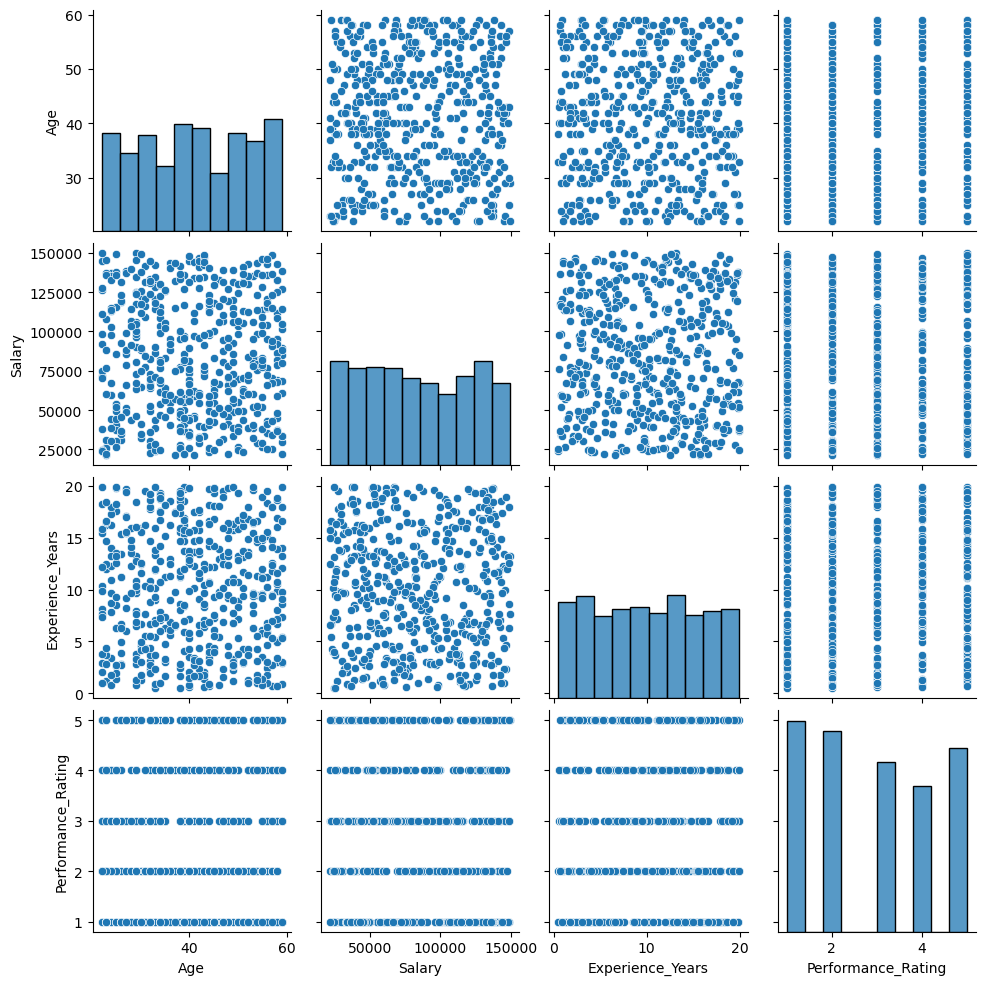

In [14]:
# checking the outlier using the seaborn 4 subplots cause of there ar e4 nemerical values
sns.pairplot(df)
plt.show()

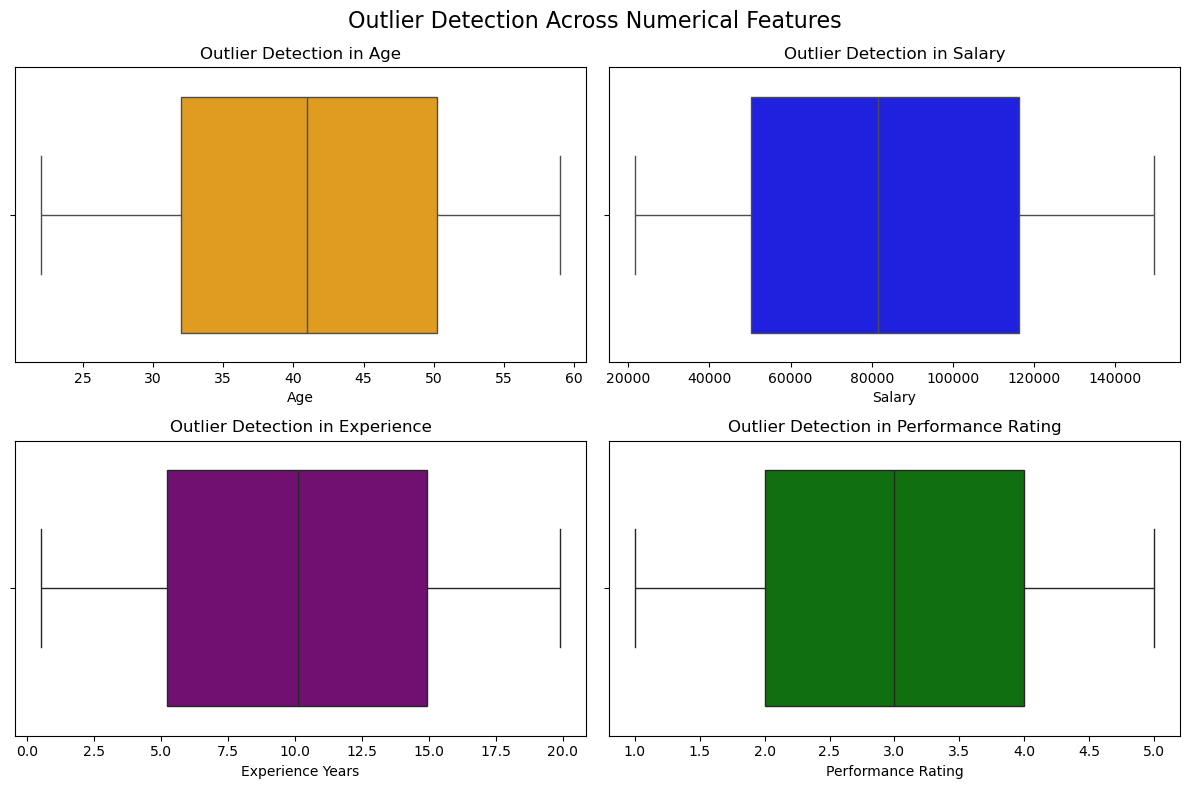

In [15]:
# checkikng the otlier  using box for age,salary,experiece,Performance_Rating

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Outlier Detection Across Numerical Features', fontsize=16)

# 1. Age (Row 0, Col 0)
sns.boxplot(x=df['Age'], color='orange', ax=axes[0, 0])
axes[0, 0].set_title('Outlier Detection in Age')
axes[0, 0].set_xlabel('Age')

# 2. Salary (Row 0, Col 1)
sns.boxplot(x=df['Salary'], color='blue', ax=axes[0, 1])
axes[0, 1].set_title('Outlier Detection in Salary')
axes[0, 1].set_xlabel('Salary')

# 3. Experience Years (Row 1, Col 0)
sns.boxplot(x=df['Experience_Years'], color='purple', ax=axes[1, 0])
axes[1, 0].set_title('Outlier Detection in Experience')
axes[1, 0].set_xlabel('Experience Years')

# 4. Performance Rating (Row 1, Col 1)
sns.boxplot(x=df['Performance_Rating'], color='green', ax=axes[1, 1])
axes[1, 1].set_title('Outlier Detection in Performance Rating')
axes[1, 1].set_xlabel('Performance Rating')

plt.tight_layout()
plt.show()


In [16]:
df.head()

,Age,Gender,Department,Designation,Salary,Experience_Years,Joining_Date,Performance_Rating
0,42,Male,Marketing,Executive,144857,13.4,2019-06-11,1
1,42,Female,IT,Manager,39738,17.5,2015-10-14,5
2,26,Female,Operations,Executive,30703,15.3,2022-09-05,2
3,41,Male,Operations,Executive,133776,14.7,2018-05-20,5
4,58,Female,HR,Executive,69422,9.9,2019-03-28,5


In [20]:
print(df.Gender.unique())
print(df.Department.unique())
print(df.Designation.unique())

print("Hear only two values are there Male and Female so we can convert as a label encoding Male = 1 and Female = 0")
print("Hear more than two values are there so we use one-hot encoding for this Department column")
print("Hear more than two values are there so we use one-hot encoding for this Designation column")

['Male' 'Female']
['Marketing' 'IT' 'Operations' 'HR' 'Finance']
['Executive' 'Manager' 'Analyst' 'Lead' 'Associate']
Hear only two values are there Male and Female so we can convert as a label encoding Male = 1 and Female = 0
Hear more than two values are there so we use one-hot encoding for this Department column
Hear more than two values are there so we use one-hot encoding for this Designation column


In [ ]:
#  Label encoding for Gender
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
# one hot encoding for Department and Designation
df = pd.get_dummies(df, columns=['Department', 'Designation'], drop_first=True)

KeyError: "None of [Index(['Department', 'Designation'], dtype='object')] are in the [columns]"

In [40]:
df.columns

Index(['Age', 'Gender', 'Salary', 'Experience_Years', 'Performance_Rating',
       'Department_HR', 'Department_IT', 'Department_Marketing',
       'Department_Operations', 'Designation_Associate',
       'Designation_Executive', 'Designation_Lead', 'Designation_Manager'],
      dtype='object')

In [30]:
# hear the joining date is not useful for the model so we can drop this column
df.drop("Joining_Date",axis = 1 , inplace = True)

In [41]:
# now we need to take a target column  
X = df.drop(['Salary'], axis=1)
y = df['Salary']

In [42]:
# now import the models  and train  the  data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Training labels size:", y_train.shape)
print("Actual Data :", y_test.shape)

Training set size: (400, 12)
Testing set size: (100, 12)
Training labels size: (400,)
Actual Data : (100,)


In [43]:
df.dtypes.tolist()

[dtype('int64'),
 dtype('float64'),
 dtype('int64'),
 dtype('float64'),
 dtype('int64'),
 dtype('bool'),
 dtype('bool'),
 dtype('bool'),
 dtype('bool'),
 dtype('bool'),
 dtype('bool'),
 dtype('bool'),
 dtype('bool')]

In [46]:
# 1. See which columns still have missing values
print(X_train.isna().sum())

# 2. Drop any columns that are entirely empty (all NaNs)
X_train = X_train.dropna(axis=1, how='all')
X_test = X_test.dropna(axis=1, how='all')

# 3. Fill any remaining NaNs with the median, and use 0 as a fallback
X_train = X_train.fillna(X_train.median()).fillna(0)
X_test = X_test.fillna(X_test.median()).fillna(0)

# 4. Now try training again
lr.fit(X_train, y_train)
print("Model trained successfully!")

Age                        0
Gender                   400
Experience_Years           0
Performance_Rating         0
Department_HR              0
Department_IT              0
Department_Marketing       0
Department_Operations      0
Designation_Associate      0
Designation_Executive      0
Designation_Lead           0
Designation_Manager        0
dtype: int64
Model trained successfully!


In [47]:
lis = df[["Experience_Years","Performance_Rating","Department_HR","Department_IT","Department_Marketing","Department_Operations","Designation_Associate","Designation_Executive","Designation_Lead","Designation_Manager"]]

df.drop(lis, axis=1, inplace=True)

In [48]:
# lets train the data using with linear regression
from sklearn.linear_model import LinearRegression

X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())
lr = LinearRegression()
lr.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [50]:
# predict the salary for the test data
y_pred = lr.predict(X_test) 
y_pred


array([67963.25345477, 81567.34272766, 75220.09247091, 74069.522023  ,
       69236.1586385 , 69760.99870504, 70066.3755154 , 92207.29748794,
       84376.97896458, 73988.6948828 , 94360.91623622, 90129.12721396,
       78649.97344172, 81716.93947778, 81471.47065117, 86222.54859255,
       99052.39121174, 88486.55670858, 82422.38560424, 83312.68272946,
       87661.48448306, 77715.39013473, 86950.55255635, 81958.71014311,
       89288.82172099, 80922.79604947, 93877.15946262, 81804.71343802,
       80253.17249624, 75070.68519806, 91168.97869501, 96555.48019965,
       86885.04444172, 68766.16306277, 86069.88519137, 70369.24626039,
       75705.14065089, 88390.41667174, 80045.48372535, 77570.44237402,
       76309.87081612, 91340.21583746, 85593.41800239, 91817.57350158,
       92299.74071293, 83595.23757977, 87528.55315063, 70886.55326033,
       77246.0789809 , 79119.22400024, 72866.95701176, 88374.44280438,
       81150.86053313, 78251.62154613, 94684.64000381, 86091.31138175,
      

In [51]:
# checking the model accuracy and performance using the metrics 
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error
print(f" R2 Score: {r2_score(y_test, y_pred)}")
print(f" Mean Squared Error: {mean_squared_error(y_test, y_pred)}")
print(f" Root Mean Squared Error: {root_mean_squared_error(y_test, y_pred)}")
print(f" Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}")   

 R2 Score: -0.11957911740596816
 Mean Squared Error: 1578019304.900546
 Root Mean Squared Error: 39724.29111891798
 Mean Absolute Error: 34118.503119135756


In [55]:
# Generalization model Ridge and Lasso Regression
from sklearn.linear_model import Ridge, Lasso
L1 = Lasso(alpha=0.1)
L2  = Ridge(alpha=1.0)



# now train the model using the Lasso and Ridge regression
L1.fit(X_train, y_train)
L2.fit(X_train, y_train)

# predict the salary for the test data
y_pred_l1 = L1.predict(X_test)
y_pred_l2 = L2.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error,root_mean_squared_error

print("Lasso:\n")
print("="*50)
print(f" Lasso R2 Score: {r2_score(y_test, y_pred_l1)}")
print(f" Lasso Mean Squared Error: {mean_squared_error(y_test, y_pred_l1)}")
print(f" Lasso Mean Absolute Error: {mean_absolute_error(y_test, y_pred_l1)}")
print(f" Lasso Root Mean Squared Error: {root_mean_squared_error(y_test, y_pred_l1)}")
print("="*50)
print("\n")
print("Ridge:\n")
print(f" Ridge R2 Score: {r2_score(y_test, y_pred_l2)}")
print(f" Ridge Mean Squared Error: {mean_squared_error(y_test, y_pred_l2)}")
print(f" Ridge Mean Absolute Error: {mean_absolute_error(y_test, y_pred_l2)}")
print(f" Ridge Root Mean Squared Error: {root_mean_squared_error(y_test, y_pred_l2)}")
print("="*50)

Lasso:

 Lasso R2 Score: -0.11955692914470184
 Lasso Mean Squared Error: 1577988031.0905256
 Lasso Mean Absolute Error: 34118.2033281216
 Lasso Root Mean Squared Error: 39723.89748111992


Ridge:

 Ridge R2 Score: -0.11549571073517817
 Ridge Mean Squared Error: 1572263843.3560362
 Ridge Mean Absolute Error: 34062.83365582779
 Ridge Root Mean Squared Error: 39651.782347784014


In [56]:
# logistic regression  
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

# now checking the accuracy of the logistic regression model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Logistic Regression:\n")
print("="*50)
print(f" Accuracy: {accuracy_score(y_test, y_pred_log)}")
print(f" Classification Report:\n {classification_report(y_test, y_pred_log)}")
print(f" Confusion Matrix:\n {confusion_matrix(y_test, y_pred_log)}")
print("="*50)

Logistic Regression:

 Accuracy: 0.0
 Classification Report:
               precision    recall  f1-score   support

       21814       0.00      0.00      0.00       1.0
       21881       0.00      0.00      0.00       1.0
       22462       0.00      0.00      0.00       1.0
       22866       0.00      0.00      0.00       0.0
       24552       0.00      0.00      0.00       0.0
       25368       0.00      0.00      0.00       0.0
       25454       0.00      0.00      0.00       1.0
       25695       0.00      0.00      0.00       0.0
       25877       0.00      0.00      0.00       0.0
       26305       0.00      0.00      0.00       1.0
       27566       0.00      0.00      0.00       0.0
       28307       0.00      0.00      0.00       0.0
       29343       0.00      0.00      0.00       0.0
       30377       0.00      0.00      0.00       1.0
       30589       0.00      0.00      0.00       1.0
       33269       0.00      0.00      0.00       0.0
       33704       

c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique

In [57]:
# decision tree regression
from sklearn.tree import DecisionTreeRegressor
dt_reg = DecisionTreeRegressor()
dt_reg.fit(X_train, y_train)
y_pred_dt = dt_reg.predict(X_test)

# predict the salary for the test data

print("Decision Tree Regression:\n")
print("="*50)
print(f" R2 Score: {r2_score(y_test, y_pred_dt)}")
print(f" Mean Squared Error: {mean_squared_error(y_test, y_pred_dt)}")
print(f" Mean Absolute Error: {mean_absolute_error(y_test, y_pred_dt)}")
print(f" Root Mean Squared Error: {root_mean_squared_error(y_test, y_pred_dt)}")
print("="*50)

Decision Tree Regression:

 R2 Score: -1.3058593609395737
 Mean Squared Error: 3250052211.03
 Mean Absolute Error: 47782.11
 Root Mean Squared Error: 57009.22917414337


In [58]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train, y_train)
y_pred_dt_clf = dt_clf.predict(X_test)

print("Decision Tree Classifier:\n")
print("="*50)
print(f" Accuracy: {accuracy_score(y_test, y_pred_dt_clf)}")
print(f" Classification Report:\n {classification_report(y_test, y_pred_dt_clf)}")
print(f" Confusion Matrix:\n {confusion_matrix(y_test, y_pred_dt_clf)}")
print("="*50)

Decision Tree Classifier:

 Accuracy: 0.0
 Classification Report:
               precision    recall  f1-score   support

       21814       0.00      0.00      0.00       1.0
       21881       0.00      0.00      0.00       1.0
       22123       0.00      0.00      0.00       0.0
       22462       0.00      0.00      0.00       1.0
       22866       0.00      0.00      0.00       0.0
       23722       0.00      0.00      0.00       0.0
       24006       0.00      0.00      0.00       0.0
       24552       0.00      0.00      0.00       0.0
       24686       0.00      0.00      0.00       0.0
       25368       0.00      0.00      0.00       0.0
       25454       0.00      0.00      0.00       1.0
       25877       0.00      0.00      0.00       0.0
       25898       0.00      0.00      0.00       0.0
       26305       0.00      0.00      0.00       1.0
       26782       0.00      0.00      0.00       0.0
       28307       0.00      0.00      0.00       0.0
       29343  

c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
c:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique class

## HYPER_PERAMETERS TUINING
 

 this is for to increase the  accuracy of the model
 

In [60]:
# now we increass the model accuracy using with linear regression  hyper parameter tuining
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Define the Ridge model
ridge = Ridge()

# Define hyperparameters to test
param_grid_ridge = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}

# Set up Grid Search with 5-fold cross-validation
grid_ridge = GridSearchCV(estimator=ridge, param_grid=param_grid_ridge, cv=5, scoring='r2')

# Fit to training data
grid_ridge.fit(X_train, y_train)

print("Best Ridge Alpha:", grid_ridge.best_params_)
print("Best Ridge R2 Score:", grid_ridge.best_score_)

Best Ridge Alpha: {'alpha': 1000.0}
Best Ridge R2 Score: -0.03396931215349182


In [61]:
from sklearn.linear_model import Lasso

# Define the Lasso model (max_iter increased to ensure convergence)
lasso = Lasso(max_iter=10000)

# Define hyperparameters to test
param_grid_lasso = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

# Set up Grid Search
grid_lasso = GridSearchCV(estimator=lasso, param_grid=param_grid_lasso, cv=5, scoring='r2')

# Fit to training data
grid_lasso.fit(X_train, y_train)

print("Best Lasso Alpha:", grid_lasso.best_params_)
print("Best Lasso R2 Score:", grid_lasso.best_score_)

Best Lasso Alpha: {'alpha': 100.0}
Best Lasso R2 Score: -0.04805272501035503


In [62]:
best_model = grid_ridge.best_estimator_ # or grid_lasso.best_estimator_
predictions = best_model.predict(X_test)

In [66]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

# 1. Initialize the Decision Tree Regressor (setting random_state for reproducibility)
dt = DecisionTreeRegressor(random_state=42)

# 2. Define the grid of hyperparameters to search through
param_grid_dt = {
    'max_depth': [3, 5, 10, 15, None],          # Controls how deep the tree can grow
    'min_samples_split': [2, 5, 10],            # Minimum samples needed to split a node
    'min_samples_leaf': [1, 2, 5],              # Minimum samples allowed in a leaf node
    'max_features': ['auto', 'sqrt', 'log2', 1.0] # Number of features to consider per split
}

# 3. Set up Grid Search with 5-fold cross-validation
grid_dt = GridSearchCV(
    estimator=dt, 
    param_grid=param_grid_dt, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1 # Uses all CPU cores to run faster
)

# 4. Fit to your training data
grid_dt.fit(X_train, y_train)

# 5. Print the results
print("Best Decision Tree Parameters:", grid_dt.best_params_)
print("Best Decision Tree R2 Score:", grid_dt.best_score_)

Best Decision Tree Parameters: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Decision Tree R2 Score: -0.04869018348374858


c:\Users\user\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
225 fits failed out of a total of 900.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
157 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\user\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py", line 471, in _validate_params
    v

In [67]:
best_dt_model = grid_dt.best_estimator_
predictions = best_dt_model.predict(X_test)

In [68]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# 1. Initialize the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# 2. Define the grid of hyperparameters to search through
param_grid_classifier = {
    'criterion': ['gini', 'entropy'],           # Function to measure the quality of a split
    'max_depth': [3, 5, 10, 15, None],          # Controls how deep the tree grows
    'min_samples_split': [2, 5, 10],            # Minimum samples needed to split a node
    'min_samples_leaf': [1, 2, 5]               # Minimum samples allowed in a leaf node
}

# 3. Set up Grid Search (using accuracy as the scoring metric for classification)
grid_classifier = GridSearchCV(
    estimator=dt_classifier, 
    param_grid=param_grid_classifier, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

# 4. Fit to your training data (make sure y_train contains categorical classes)
grid_classifier.fit(X_train, y_train)

# 5. Print the results
print("Best Classifier Parameters:", grid_classifier.best_params_)
print("Best Classifier Accuracy Score:", grid_classifier.best_score_)

ValueError: n_splits=5 cannot be greater than the number of members in each class.

In [69]:
best_classifier = grid_classifier.best_estimator_
predictions = best_classifier.predict(X_test)

AttributeError: 'GridSearchCV' object has no attribute 'best_estimator_'